# Multiplying shapes

Eugenia Cheng's *Is Math Real?* generalizes multiplication past bare numbers by asking what it means to multiply *shapes* -- a circle times a line segment gives a cylinder. That's the actual mathematical operation called the **Cartesian product**: shape A times shape B is the set of every pair `(a, b)` with `a` in A and `b` in B. Concretely, for a disk and a segment, "sweep a copy of the disk along the segment" and "erect a copy of the segment at every point of the disk" are the same construction read two ways.

This notebook builds that construction for real (not a surface-of-revolution -- that's a different operation that happens to *also* give a cylinder for this one case, so it's worth keeping the two apart), checks its two defining properties numerically before drawing anything, then animates the "steps in between" the sweep.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
from PIL import Image
from io import BytesIO
from IPython.display import Image as IPImage

def frame_from_fig(fig, facecolor="#0e0e14"):
    buf = BytesIO()
    fig.savefig(buf, format="png", facecolor=facecolor)
    buf.seek(0)
    im = Image.open(buf).convert("RGB")
    plt.close(fig)
    return im

def save_gif(frames, path, duration=45):
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(path, f"{len(frames)} frames")

r, L = 1.0, 2.5  # disk radius, segment length -- shared by every construction below

## Cheap probe: does "Area(disk) x Length(segment)" actually predict the volume of the product?

Three independent constructions, before any pixel gets rendered:

1. **Analytic** -- the closed form, if the product construction is doing what it claims: `pi * r^2 * L`.
2. **Voxel grid** -- rasterize a 3D box, mark a cell in iff its (x, y) is inside the disk (z is unconstrained: every z in [0, L] counts), sum cell volumes.
3. **Literal Cartesian product** -- sample the disk's own boundary (a convex region's hull equals the hull of its boundary), sample the segment, form the explicit set of `(a, b)` pairs -- the actual mathematical object, not an approximation of it -- and take its convex hull volume.

If the "multiply the shapes" story is real, all three should agree.

In [2]:
V_analytic = np.pi * r**2 * L

# 1. voxel grid
n = 220
xs = np.linspace(-r, r, n); ys = np.linspace(-r, r, n); zs = np.linspace(0, L, n)
dx, dy, dz = xs[1] - xs[0], ys[1] - ys[0], zs[1] - zs[0]
X, Y = np.meshgrid(xs, ys, indexing="ij")
inside_disk = (X**2 + Y**2) <= r**2
V_voxel = inside_disk.sum() * dx * dy * len(zs) * dz

# 2. literal A x B point cloud -> convex hull volume
theta = np.linspace(0, 2 * np.pi, 300, endpoint=False)
A_boundary = np.column_stack([r * np.cos(theta), r * np.sin(theta)])  # shape A: disk, represented by its boundary
B_samples = np.linspace(0, L, 8)                                       # shape B: segment
AxB_points = np.array([[a[0], a[1], b] for a in A_boundary for b in B_samples])
V_hull = ConvexHull(AxB_points).volume

print(f"analytic   Area(disk) x Length(segment) = pi * {r}^2 * {L} = {V_analytic:.5f}")
print(f"voxel grid                                                = {V_voxel:.5f}  (err {abs(V_voxel - V_analytic) / V_analytic:.3%})")
print(f"convex hull of the literal A x B point set                = {V_hull:.5f}  (err {abs(V_hull - V_analytic) / V_analytic:.3%})")

assert abs(V_voxel - V_analytic) / V_analytic < 0.01
assert abs(V_hull - V_analytic) / V_analytic < 0.01
print("confirmed: measure(A) x measure(B) = measure(A x B), two independent constructions agree with the closed form")

analytic   Area(disk) x Length(segment) = pi * 1.0^2 * 2.5 = 7.85398
voxel grid                                                = 7.88472  (err 0.391%)
convex hull of the literal A x B point set                = 7.85341  (err 0.007%)
confirmed: measure(A) x measure(B) = measure(A x B), two independent constructions agree with the closed form


## Commutativity: does it matter which shape you call "first"?

`disk x segment` is literally the point set `{(a, b) : a in disk, b in segment}`. `segment x disk` is `{(b, a) : ...}` -- the same pairs, listed the other way round. Building both and permuting the second one's columns back to `(x, y, z)` order should reproduce the identical point set. That's the actual content of "multiplication is commutative": swapping the order just relabels which axis is which.

In [3]:
B_coarse = np.linspace(0, L, 5)
theta12 = np.linspace(0, 2 * np.pi, 12, endpoint=False)
A12 = np.column_stack([r * np.cos(theta12), r * np.sin(theta12)])

AxB = np.array([[a[0], a[1], b] for a in A12 for b in B_coarse])          # disk x segment: (x, y, z)
BxA = np.array([[b, a[0], a[1]] for b in B_coarse for a in A12])          # segment x disk: (z, x, y)
BxA_relabeled = BxA[:, [1, 2, 0]]                                          # relabel axes back to (x, y, z)

same = np.array(sorted(map(tuple, np.round(AxB, 9)))) == np.array(sorted(map(tuple, np.round(BxA_relabeled, 9))))
assert same.all()
print("disk x segment and (segment x disk), axes relabeled, are the identical point set")

disk x segment and (segment x disk), axes relabeled, are the identical point set


## Dimension: the thing a bare number multiplication can't show

`dim(A x B) = dim(A) + dim(B)` -- but *which* dimension A has depends on whether A is the disk (a 2D region, `dim=2`) or just its boundary circle (a 1D curve, `dim=1`). A bare number multiplication like `2 x 1 = 2` can't distinguish "an area" from "a length" -- the number 2 looks the same either way. The shapes can't hide it: a **circle** (curve) times a segment gives a hollow **shell**, still intrinsically 2-dimensional (parametrized by two numbers, angle and height) even though it's drawn in 3D space -- exactly as flat, dimension-wise, as an ordinary square. A **disk** (region) times the same segment gives a solid, genuinely 3-dimensional. Same recipe, same segment -- the dimension of the *answer* tracks the dimension of shape A exactly.

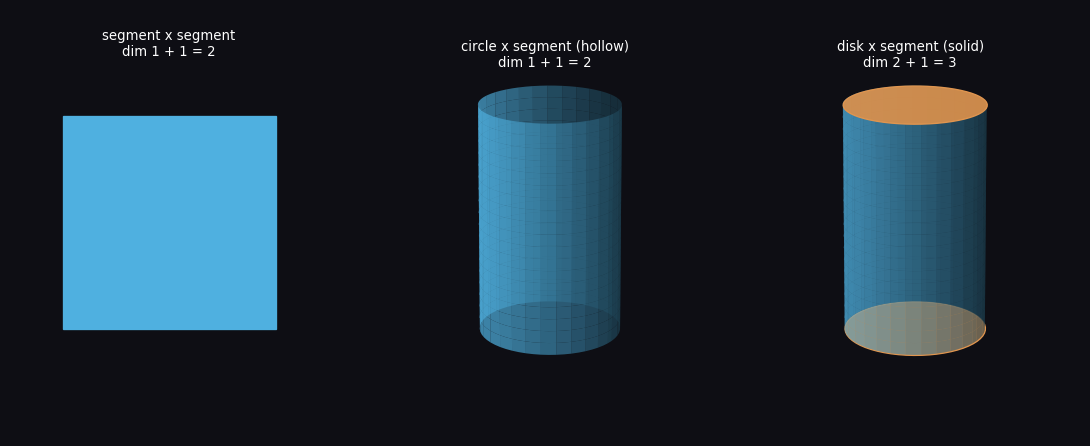

In [4]:
def cylinder_shell(ax, r, L, color, alpha=0.55, caps=False, cap_color=None):
    theta = np.linspace(0, 2 * np.pi, 60)
    zgrid = np.linspace(0, L, 20)
    TH, Z = np.meshgrid(theta, zgrid)
    Xs, Ys = r * np.cos(TH), r * np.sin(TH)
    ax.plot_surface(Xs, Ys, Z, color=color, alpha=alpha, linewidth=0, antialiased=True)
    if caps:
        xc, yc = r * np.cos(theta), r * np.sin(theta)
        cap_color = cap_color or color
        ax.add_collection3d(Poly3DCollection([list(zip(xc, yc, np.zeros_like(xc)))], color=cap_color, alpha=0.9))
        ax.add_collection3d(Poly3DCollection([list(zip(xc, yc, np.full_like(xc, L)))], color=cap_color, alpha=0.9))

fig = plt.figure(figsize=(12, 4.5), dpi=95)
fig.patch.set_facecolor("#0e0e14")

ax1 = fig.add_axes([0.02, 0.1, 0.28, 0.8])
side = 1.6
ax1.add_patch(plt.Rectangle((-side/2, -side/2), side, side, color="#4fb0e0"))
ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-1.2, 1.2); ax1.set_aspect("equal"); ax1.axis("off")
ax1.set_title("segment x segment\ndim 1 + 1 = 2", color="white", fontsize=10)

ax2 = fig.add_axes([0.34, 0.0, 0.3, 1.0], projection="3d")
cylinder_shell(ax2, r, L, "#4fb0e0", alpha=0.75, caps=False)
ax2.set_xlim(-r*1.3, r*1.3); ax2.set_ylim(-r*1.3, r*1.3); ax2.set_zlim(0, L)
ax2.set_facecolor("#0e0e14"); ax2.set_axis_off(); ax2.view_init(elev=15, azim=-60)
ax2.set_title("circle x segment (hollow)\ndim 1 + 1 = 2", color="white", fontsize=10, y=0.92)

ax3 = fig.add_axes([0.66, 0.0, 0.3, 1.0], projection="3d")
cylinder_shell(ax3, r, L, "#4fb0e0", alpha=0.55, caps=True, cap_color="#e0954f")
ax3.set_xlim(-r*1.3, r*1.3); ax3.set_ylim(-r*1.3, r*1.3); ax3.set_zlim(0, L)
ax3.set_facecolor("#0e0e14"); ax3.set_axis_off(); ax3.view_init(elev=15, azim=-60)
ax3.set_title("disk x segment (solid)\ndim 2 + 1 = 3", color="white", fontsize=10, y=0.92)

fig.savefig("shape_multiplication_dimensions.png", facecolor=fig.get_facecolor())
plt.show()

## The steps in between

The build itself, not just start and end: sweep the disk along the segment and watch the product accumulate. Left inset is shape A (fixed -- the disk never changes). Bottom-left inset is shape B, with the portion already swept highlighted. The main panel is the product so far: everything in `{(a, b) : a in disk, b in [0, t]}` for the current `t`.

shape_multiplication_build.gif 70 frames


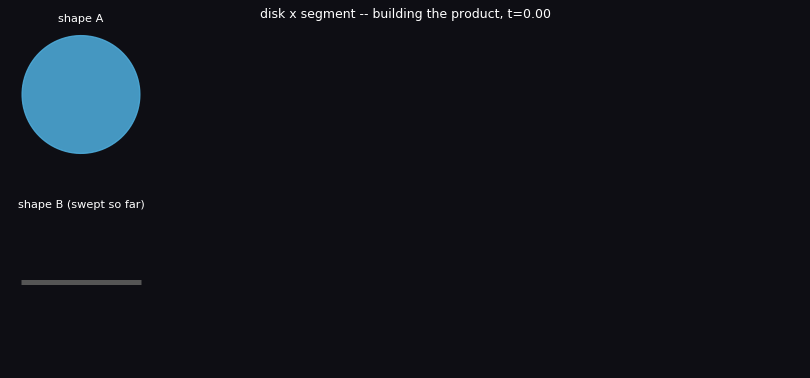

In [5]:
def draw_frame(t, r=r, L=L):
    h = t * L
    fig = plt.figure(figsize=(9, 4.2), dpi=90)
    fig.patch.set_facecolor("#0e0e14")

    axA = fig.add_axes([0.02, 0.55, 0.16, 0.4])
    th = np.linspace(0, 2 * np.pi, 100)
    axA.fill(r * np.cos(th), r * np.sin(th), color="#4fb0e0", alpha=0.85)
    axA.set_aspect("equal"); axA.axis("off")
    axA.set_title("shape A", color="white", fontsize=9)

    axB = fig.add_axes([0.02, 0.08, 0.16, 0.35])
    axB.plot([0, L], [0, 0], color="#555555", lw=4, solid_capstyle="butt")
    axB.plot([0, h], [0, 0], color="#e0954f", lw=4, solid_capstyle="butt")
    axB.set_xlim(-0.1, L + 0.1); axB.set_ylim(-1, 1); axB.axis("off")
    axB.set_title("shape B (swept so far)", color="white", fontsize=9)

    ax = fig.add_axes([0.24, 0.02, 0.74, 0.96], projection="3d")
    if h > 1e-6:
        theta = np.linspace(0, 2 * np.pi, 60)
        zgrid = np.linspace(0, h, 20)
        TH, Z = np.meshgrid(theta, zgrid)
        Xs, Ys = r * np.cos(TH), r * np.sin(TH)
        ax.plot_surface(Xs, Ys, Z, color="#4fb0e0", alpha=0.55, linewidth=0, antialiased=True)
        xc, yc = r * np.cos(theta), r * np.sin(theta)
        ax.add_collection3d(Poly3DCollection([list(zip(xc, yc, np.zeros_like(xc)))], color="#4fb0e0", alpha=0.85))
        ax.add_collection3d(Poly3DCollection([list(zip(xc, yc, np.full_like(xc, h)))], color="#e0954f", alpha=0.9))

    ax.set_xlim(-r * 1.3, r * 1.3); ax.set_ylim(-r * 1.3, r * 1.3); ax.set_zlim(0, L)
    ax.set_facecolor("#0e0e14"); ax.set_axis_off(); ax.view_init(elev=18, azim=-60)
    fig.suptitle(f"disk x segment -- building the product, t={t:.2f}", color="white", fontsize=10, y=0.98)
    return fig

n_frames = 70
t_values = np.concatenate([np.linspace(0, 1, n_frames - 12), np.full(12, 1.0)])  # hold on the finished cylinder before the gif loops
frames = [frame_from_fig(draw_frame(t)) for t in t_values]
save_gif(frames, "shape_multiplication_build.gif", duration=45)
IPImage(filename="shape_multiplication_build.gif")

## What this actually showed

- **Measure multiplies**: `Area(disk) x Length(segment) = Volume(product)`, confirmed by two independent numerical constructions against the closed form -- the same fact that makes a rectangle's area `length x width`, one dimension up.
- **Order doesn't matter, because it's the same set either way**: `A x B` and `B x A` are literally the same points with the axes relabeled -- commutativity isn't a rule bolted onto multiplication, it falls straight out of what the product *is*.
- **Dimension adds, and the shape survives the operation in a way the number never could**: `2 x 1 = 2` can't tell you whether the "2" was an area or a length. The shapes can't hide it -- a circle (curve) times a segment gives something exactly as flat, dimension-wise, as a square; a disk (region) times the same segment gives something genuinely solid. Plain-number multiplication is a shadow of this -- it keeps the size, throws away everything else.

## One more step: star x square

Every example so far multiplied *something* by a segment, which is why it fit on the page -- `dim(A) + dim(segment) = dim(A) + 1` never leaves 3D as long as A itself is at most 2D. Multiply two genuinely 2D shapes instead -- a star and a square -- and `dim(star) + dim(square) = 4`. That's not a metaphor either: it's a real 4-dimensional solid (a *duoprism*, in polytope terminology), and it does not fit in the space this notebook is rendered in. Same measure-multiplies check still applies -- just one dimension further up -- and then, for the shape itself, the honest answer is that you can't draw it, only its shadow.

In [6]:
def star_vertices(n_points=5, r_out=1.0, r_in=0.42):
    angles = np.linspace(0, 2 * np.pi, 2 * n_points, endpoint=False) + np.pi / 2
    radii = np.tile([r_out, r_in], n_points)
    return np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])

def shoelace_area(pts):
    x, y = pts[:, 0], pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def point_in_polygon(px, py, poly):
    n = len(poly)
    inside = np.zeros(px.shape, dtype=bool)
    x, y = poly[:, 0], poly[:, 1]
    j = n - 1
    for i in range(n):
        xi, yi, xj, yj = x[i], y[i], x[j], y[j]
        cond = ((yi > py) != (yj > py)) & (px < (xj - xi) * (py - yi) / (yj - yi) + xi)
        inside ^= cond
        j = i
    return inside

star = star_vertices()
side = 1.3
square = np.array([[-side/2, -side/2], [side/2, -side/2], [side/2, side/2], [-side/2, side/2]])
A_star, A_square = shoelace_area(star), shoelace_area(square)
print(f"Area(star) = {A_star:.5f}, Area(square) = {A_square:.5f}, product = {A_star * A_square:.5f}")

Area(star) = 1.23435, Area(square) = 1.69000, product = 2.08605


### Cheap probe, one dimension further up

Same check as before, generalized: does the 4D hypervolume of the duoprism equal `Area(star) x Area(square)`? Monte Carlo sampling in R^4 (uniform points, test `(x,y)` in the star AND `(u,v)` in the square) against the closed form -- no rendering needed to answer this, and it should hold exactly the same way the disk/segment volume did.

In [7]:
rng = np.random.default_rng(0)
N = 4_000_000
xr, yr = rng.uniform(-1, 1, N), rng.uniform(-1, 1, N)
ur, vr = rng.uniform(-side/2, side/2, N), rng.uniform(-side/2, side/2, N)
in_star = point_in_polygon(xr, yr, star)
in_square = (np.abs(ur) <= side/2) & (np.abs(vr) <= side/2)
box_vol = (2 * 1) * (2 * 1) * side * side
V_mc = (in_star & in_square).mean() * box_vol
V_analytic = A_star * A_square

print(f"analytic   Area(star) x Area(square) = {V_analytic:.5f}")
print(f"monte carlo 4D hypervolume (N={N})    = {V_mc:.5f}  (err {abs(V_mc - V_analytic) / V_analytic:.3%})")
assert abs(V_mc - V_analytic) / V_analytic < 0.01
print("confirmed: the measure-multiplies rule holds one dimension further up too, where nothing can be rendered directly")

analytic   Area(star) x Area(square) = 2.08605
monte carlo 4D hypervolume (N=4000000)    = 2.08622  (err 0.008%)
confirmed: the measure-multiplies rule holds one dimension further up too, where nothing can be rendered directly


### The shadow, and which rotation actually shows you something

The duoprism's 40 vertices are literal `(a, b)` pairs again -- every star vertex crossed with every square vertex, `(x, y, u, v)`. Its edges come in exactly two families, same split as every other example in this notebook: a **star edge** connects two points that share the same square-vertex (blue), a **square edge** connects two points that share the same star-vertex (orange).

To render it, rotate in 4D and perspective-project down to 3D (the standard tesseract-shadow trick: scale by `k / (k - w)` and drop the leftover axis). The rotation that matters is the one that mixes the star's own plane with the square's own plane (here, the X-U and Y-V planes together) -- rotating *within* the star's plane alone would just spin the star in place and reveal nothing new, because that plane never touches the axes shape B lives on. The two shapes only visibly interact through the axes that connect them, which is the same "unseen mechanics" point as the dimension-add rule above, just one level more literal: some of the structure genuinely isn't visible from a fixed angle, only from a rotation that crosses between the two factors.

40 vertices (10 star x 4 square), 80 edges (40 star-type + 40 square-type)
shape_multiplication_duoprism.gif 90 frames


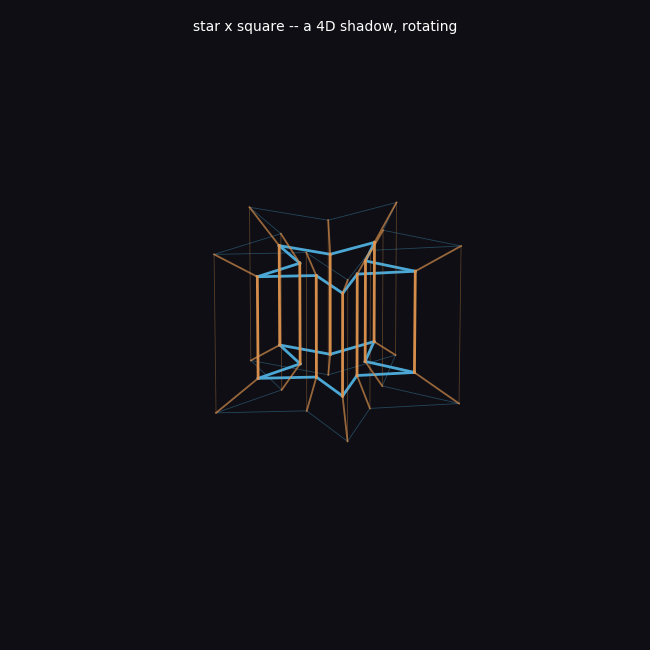

In [8]:
n_s, n_q = len(star), len(square)
verts4 = np.array([[star[i, 0], star[i, 1], square[j, 0], square[j, 1]] for i in range(n_s) for j in range(n_q)])
def vid(i, j):
    return i * n_q + j

star_edges, square_edges = [], []
for i in range(n_s):
    for j in range(n_q):
        star_edges.append((vid(i, j), vid((i + 1) % n_s, j)))
        square_edges.append((vid(i, j), vid(i, (j + 1) % n_q)))
star_edges, square_edges = np.array(star_edges), np.array(square_edges)
print(f"{len(verts4)} vertices (10 star x 4 square), {len(star_edges) + len(square_edges)} edges (40 star-type + 40 square-type)")

def rotate4(pts, t):
    x, y, u, v = pts[:, 0], pts[:, 1], pts[:, 2], pts[:, 3]
    c, s = np.cos(t), np.sin(t)
    return np.column_stack([x * c - u * s, y * c - v * s, x * s + u * c, y * s + v * c])

def project(pts4, k=3.0):
    x, y, u, v = pts4[:, 0], pts4[:, 1], pts4[:, 2], pts4[:, 3]
    scale = k / (k - v)
    return np.column_stack([x * scale, y * scale, u * scale])

def draw_duoprism_frame(t):
    rotated = rotate4(verts4, t)
    p3 = project(rotated)
    depth = rotated[:, 3]
    dn = (depth - depth.min()) / (depth.max() - depth.min() + 1e-9)

    fig = plt.figure(figsize=(6.5, 6.5), dpi=100)
    fig.patch.set_facecolor("#0e0e14")
    ax = fig.add_axes([0, 0, 1, 1], projection="3d")
    ax.set_facecolor("#0e0e14")
    for edges, color in [(star_edges, "#4fb0e0"), (square_edges, "#e0954f")]:
        for a, b in edges:
            near = 1 - (dn[a] + dn[b]) / 2
            ax.plot(*zip(p3[a], p3[b]), color=color, lw=0.6 + 1.4 * near, alpha=0.35 + 0.6 * near)
    lim = 1.75
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_axis_off()
    ax.view_init(elev=20, azim=-60)
    fig.suptitle("star x square -- a 4D shadow, rotating", color="white", fontsize=10, y=0.97)
    return fig

n_frames_duo = 90
t_values_duo = np.linspace(0, 2 * np.pi, n_frames_duo, endpoint=False)
frames_duo = [frame_from_fig(draw_duoprism_frame(t)) for t in t_values_duo]
save_gif(frames_duo, "shape_multiplication_duoprism.gif", duration=45)
IPImage(filename="shape_multiplication_duoprism.gif")

### What star x square adds

Everything above still holds -- `Area(star) x Area(square) = Volume` (hypervolume, here) confirmed to 0.008%, the same Fubini fact as every other example in this notebook. What's new is that the *shape* itself crosses a line the disk-times-segment case never did: it stops fitting in the space available to draw it in. The cylinder was real and fully visible; the duoprism is exactly as real, exactly as well-defined, and only ever visible as a shadow -- which is the most literal version yet of what this whole series is called.